In [712]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

<h1>Exploratory Data Analysis / Preprocessing</h1>

In [713]:
X_train=pd.read_csv('train.csv')
Y_train=pd.read_csv('train.csv', usecols=['Survived'])
X_test=pd.read_csv('test.csv')
Y_test=pd.read_csv('gender_submission.csv')
X=pd.read_csv('train.csv')

In [714]:
X_train=X_train.drop(columns=['PassengerId','Survived'])
X_test=X_test.drop(columns=['PassengerId'])


In [715]:
print(X_train.shape)
print(Y_train.shape)

(891, 10)
(891, 1)


In [716]:
X_train.isna().sum()

Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare          0
Cabin       687
Embarked      2
dtype: int64

In [717]:
X_train['Cabin'].str[0].unique()

array([nan, 'C', 'E', 'G', 'D', 'A', 'B', 'F', 'T'], dtype=object)

In [718]:
X_train

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...
886,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [719]:
def preprocessing(X_train):
    X_train['Has_Cabin']=~X_train['Cabin'].isna()
  # 1 X_train['Ticket_Prefix'] = X_train['Ticket'].str.replace('[^A-Za-z]', '', regex=True)   #
  #  1X_train['Ticket_Prefix'].replace('', 'NONE', inplace=True)  # no prefix case
   # 2ticket_counts = X_train['Ticket'].value_counts()
   # 2X_train['Ticket_GroupSize'] = X_train['Ticket'].map(ticket_counts)
   # 2X_train['Is_Shared_Ticket'] = (X_train['Ticket_GroupSize'] > 1).astype(int)
    X_train['Title'] = X_train['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
    title_mapping = {
        "Mlle": "Miss",
        "Ms": "Miss",
        "Mme": "Mrs",
        "Lady": "Royalty",
        "Countess": "Royalty",
        "Dona": "Royalty",
        "Dr": "Officer",
        "Rev": "Officer",
        "Col": "Officer",
        "Major": "Officer",
        "Capt": "Officer",
        "Sir": "Royalty",
        "Don": "Royalty",
        "Jonkheer": "Royalty"
    }

    X_train['Title'] = X_train['Title'].replace(title_mapping)

    X_train['Cabin_Class'] = X_train['Cabin'].str[0]
    X_train['Cabin_Class'] = X_train['Cabin_Class'].fillna('Unknown')
    X_train['Age'] = X_train['Age'].fillna(X_train['Age'].median())
    X_train=pd.get_dummies(X_train,columns=['Embarked','Sex','Cabin_Class','Pclass','Title'], drop_first=True)
    X_train.drop(['Cabin','Ticket','Name'], axis=1, inplace=True)

    return X_train
""" X_train['Fam_Count']=X_train['Parch']+X_train['SibSp']
    X_train['Is_alone']=X_train[X_train['Fam_Count']==0].astype(int)"""


 

<>:8: SyntaxWarning: invalid escape sequence '\.'
<>:8: SyntaxWarning: invalid escape sequence '\.'
/var/folders/t1/x0nf2pv52cdbz1_9h5q9ctzc0000gn/T/ipykernel_77943/4095590265.py:8: SyntaxWarning: invalid escape sequence '\.'
  X_train['Title'] = X_train['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


" X_train['Fam_Count']=X_train['Parch']+X_train['SibSp']\n    X_train['Is_alone']=X_train[X_train['Fam_Count']==0].astype(int)"

In [720]:
X_train=preprocessing(X_train)

In [721]:
X_train=X_train.drop('Cabin_Class_T',axis=1)

In [722]:
Y_train

,Survived
0,0
1,1
2,1
3,1
4,0
...,...
886,0
887,1
888,0
889,1


In [723]:
Y_train.nunique()

Survived    2
dtype: int64

<h2>Outlier Detection</h2>

In [724]:
X_train.describe()

,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000
mean,29.361582,0.523008,0.381594,32.204208
std,13.019697,1.102743,0.806057,49.693429
min,0.420000,0.000000,0.000000,0.000000
25%,22.000000,0.000000,0.000000,7.910400
50%,28.000000,0.000000,0.000000,14.454200
75%,35.000000,1.000000,0.000000,31.000000
max,80.000000,8.000000,6.000000,512.329200


<Axes: >

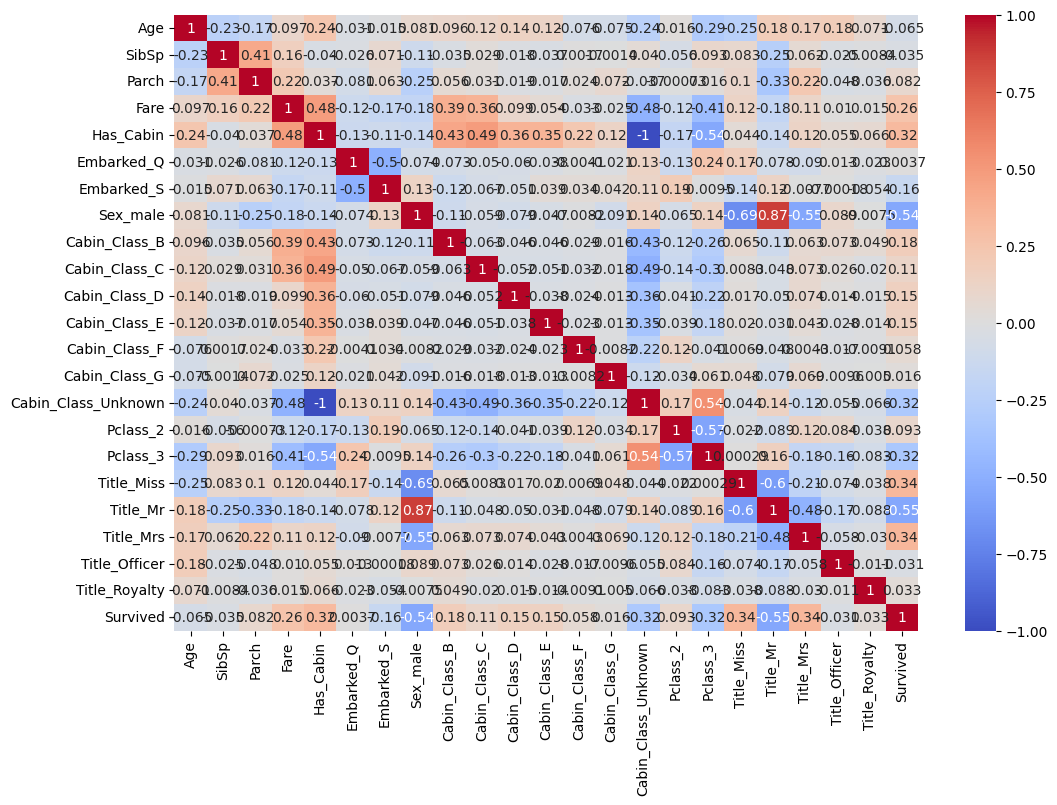

In [725]:
data=pd.concat([X_train,Y_train],axis=1)
corr=data.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm')

In [726]:
X_train

,Age,SibSp,Parch,Fare,Has_Cabin,Embarked_Q,Embarked_S,Sex_male,Cabin_Class_B,Cabin_Class_C,...,Cabin_Class_F,Cabin_Class_G,Cabin_Class_Unknown,Pclass_2,Pclass_3,Title_Miss,Title_Mr,Title_Mrs,Title_Officer,Title_Royalty
0,22.0,1,0,7.2500,False,False,True,True,False,False,...,False,False,True,False,True,False,True,False,False,False
1,38.0,1,0,71.2833,True,False,False,False,False,True,...,False,False,False,False,False,False,False,True,False,False
2,26.0,0,0,7.9250,False,False,True,False,False,False,...,False,False,True,False,True,True,False,False,False,False
3,35.0,1,0,53.1000,True,False,True,False,False,True,...,False,False,False,False,False,False,False,True,False,False
4,35.0,0,0,8.0500,False,False,True,True,False,False,...,False,False,True,False,True,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,27.0,0,0,13.0000,False,False,True,True,False,False,...,False,False,True,True,False,False,False,False,True,False
887,19.0,0,0,30.0000,True,False,True,False,True,False,...,False,False,False,False,False,True,False,False,False,False
888,28.0,1,2,23.4500,False,False,True,False,False,False,...,False,False,True,False,True,True,False,False,False,False
889,26.0,0,0,30.0000,True,False,False,True,False,True,...,False,False,False,False,False,False,True,False,False,False


In [727]:
Xmean=X_train.mean()
Xstd=X_train.std()
def norm(X):
    return ((X-Xmean)/Xstd)

In [728]:
for i in ['Age','Fare']:
    Xmean=X_train[i].mean()
    Xstd=X_train[i].std()
    X_train[i]=norm(X_train[i])
    X_test[i]=norm(X_test[i])

In [729]:
X_train

,Age,SibSp,Parch,Fare,Has_Cabin,Embarked_Q,Embarked_S,Sex_male,Cabin_Class_B,Cabin_Class_C,...,Cabin_Class_F,Cabin_Class_G,Cabin_Class_Unknown,Pclass_2,Pclass_3,Title_Miss,Title_Mr,Title_Mrs,Title_Officer,Title_Royalty
0,-0.565419,1,0,-0.502163,False,False,True,True,False,False,...,False,False,True,False,True,False,True,False,False,False
1,0.663488,1,0,0.786404,True,False,False,False,False,True,...,False,False,False,False,False,False,False,True,False,False
2,-0.258192,0,0,-0.488580,False,False,True,False,False,False,...,False,False,True,False,True,True,False,False,False,False
3,0.433068,1,0,0.420494,True,False,True,False,False,True,...,False,False,False,False,False,False,False,True,False,False
4,0.433068,0,0,-0.486064,False,False,True,True,False,False,...,False,False,True,False,True,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,-0.181385,0,0,-0.386454,False,False,True,True,False,False,...,False,False,True,True,False,False,False,False,True,False
887,-0.795839,0,0,-0.044356,True,False,True,False,True,False,...,False,False,False,False,False,True,False,False,False,False
888,-0.104579,1,2,-0.176164,False,False,True,False,False,False,...,False,False,True,False,True,True,False,False,False,False
889,-0.258192,0,0,-0.044356,True,False,False,True,False,True,...,False,False,False,False,False,False,True,False,False,False


In [730]:
X_train.isna().sum()

Age                    0
SibSp                  0
Parch                  0
Fare                   0
Has_Cabin              0
Embarked_Q             0
Embarked_S             0
Sex_male               0
Cabin_Class_B          0
Cabin_Class_C          0
Cabin_Class_D          0
Cabin_Class_E          0
Cabin_Class_F          0
Cabin_Class_G          0
Cabin_Class_Unknown    0
Pclass_2               0
Pclass_3               0
Title_Miss             0
Title_Mr               0
Title_Mrs              0
Title_Officer          0
Title_Royalty          0
dtype: int64

In [731]:
X_train = X_train.to_numpy()
Y_train = Y_train.to_numpy()


<h1>Training</h1>

In [732]:
def z_calc(X,W,B):
    Z=np.matmul(X,W)+B
    Z = np.clip(Z, -500, 500)
    return Z

def g_calc(Z):
    Z = np.array(Z, dtype=float)
    return 1/(1+np.exp(-Z))

def compute_cost(Y_train,G_train,W_train,lambd=0):
    epsilon=1e-15
    G_train=np.clip(G_train, epsilon, 1 - epsilon)
    cost=-(Y_train*np.log(G_train)+(1-Y_train)*np.log(1-G_train))/G_train.shape[0]
    reg = (lambd / (2 * Y_train.size)) * np.sum(W_train**2)
    return cost.sum()+reg

In [733]:
W_train = np.ones((X_train.shape[1], 1))
B_train= 0.0

In [734]:
Z_train=z_calc(X_train,W_train,B_train)
G_train=g_calc(Z_train)
P_train=np.round(G_train)

In [735]:
print(X_train.shape)
print(Y_train.shape)
print(Z_train.shape)

(891, 22)
(891, 1)
(891, 1)


In [736]:
W_history=[]
B_history=[]
P_history=[]
J_history=[]
W_history.append(W_train)
B_history.append(B_train)
P_history.append(P_train)
J_history.append(compute_cost(Y_train,G_train,W_train))

In [737]:
def gradescent(epoch, alpha, W_history, J_history, B_history, P_history, X_train, Y_train, lambd=0):
    for i in range(epoch):
        W_current = W_history[-1]
        B_current = B_history[-1]

        Z_train = z_calc(X_train, W_current, B_current)
        G_train = g_calc(Z_train)

        # Gradient updates
        W_new = W_current - alpha* (X_train.T @ (G_train - Y_train) + lambd * W_current) / X_train.shape[0] 
        B_new = B_current - alpha / X_train.shape[0] * np.sum(G_train - Y_train)

        # Append new weights and biases
        W_history.append(W_new.copy())
        B_history.append(B_new)

        # Prediction and cost
        Z_train = z_calc(X_train, W_new, B_new)
        G_train = g_calc(Z_train)
        P_history.append(np.round(G_train))
        J_history.append(compute_cost(Y_train, G_train,W_history[-1]))

        if i % 10 == 0:
            print("Iteration:", i, "Cost:", J_history[-1])


In [738]:
epoch=3000
alpha=4.5
gradescent(epoch, alpha, W_history, J_history, B_history, P_history, X_train, Y_train)

Iteration: 0 Cost: 1.6353275065154929
Iteration: 10 Cost: 0.514154415540629
Iteration: 20 Cost: 0.4710029230453707
Iteration: 30 Cost: 0.46550653011323373
Iteration: 40 Cost: 0.4592121005999285
Iteration: 50 Cost: 0.45547179240121916
Iteration: 60 Cost: 0.4524956996167062
Iteration: 70 Cost: 0.4501560986026289
Iteration: 80 Cost: 0.44821637735951114
Iteration: 90 Cost: 0.4465691034220062
Iteration: 100 Cost: 0.44514294143886357
Iteration: 110 Cost: 0.4438899068341388
Iteration: 120 Cost: 0.4427767059311368
Iteration: 130 Cost: 0.4417787743731049
Iteration: 140 Cost: 0.440877544412739
Iteration: 150 Cost: 0.44005856189777703
Iteration: 160 Cost: 0.43931034116934986
Iteration: 170 Cost: 0.4386235975416737
Iteration: 180 Cost: 0.43799071662575684
Iteration: 190 Cost: 0.43740537704062815
Iteration: 200 Cost: 0.43686227423507273
Iteration: 210 Cost: 0.43635691428874834
Iteration: 220 Cost: 0.4358854572269944
Iteration: 230 Cost: 0.43544459621584997
Iteration: 240 Cost: 0.4350314632534093
It

In [739]:
"""
1- Initial Cost: 0.5385007707265328
2- Cost after not normalising categorical variables: 0.4478993080479844
3- Best: 0.42355900984175"""

'\n1- Initial Cost: 0.5385007707265328\n2- Cost after not normalising categorical variables: 0.4478993080479844\n3- Best: 0.42355900984175'

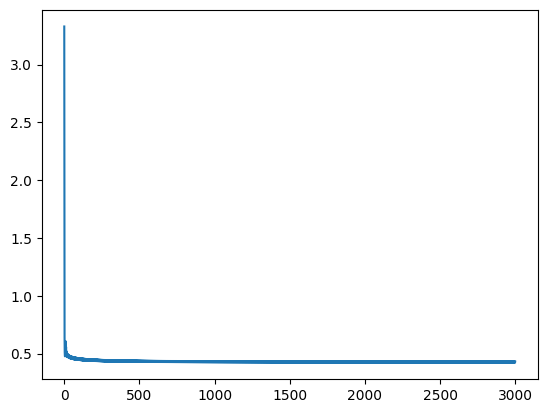

In [740]:
plt.plot(J_history)

In [741]:
W_train=W_history[-1]
B_train=B_history[-1]
Z_train=z_calc(X_train,W_train,B_train)
G_train=g_calc(Z_train)
P_train=np.round(G_train)

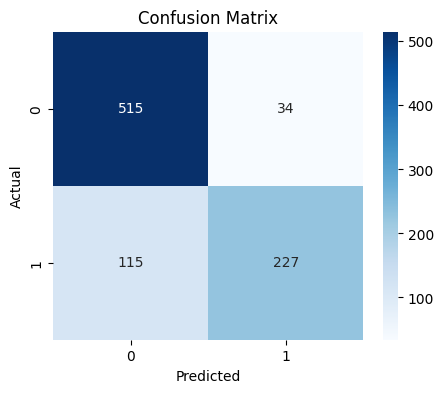

In [742]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(Y_train, P_train)  
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()



In [743]:
from sklearn.metrics import classification_report
print(classification_report(Y_train, P_train))


              precision    recall  f1-score   support

           0       0.82      0.94      0.87       549
           1       0.87      0.66      0.75       342

    accuracy                           0.83       891
   macro avg       0.84      0.80      0.81       891
weighted avg       0.84      0.83      0.83       891



In [744]:
count=0
for i in range(len(P_train)):
    if (P_train[i]==Y_train[i]):
        count+=1
print("Accuracy: ",count*100/len(P_train))

Accuracy:  83.27721661054994


In [745]:
"""
Accuracy 1 (Initial): 76.767676
Accuracy 2 (Fixing normalisation problem): 79.2368125701459
Accuracy 3 (got dummies for Pclass too and drop_first=True): 82.04264870931537 
Accuracy 4 (using titles from names) 83.27721661054994

"""

'\nAccuracy 1 (Initial): 76.767676\nAccuracy 2 (Fixing normalisation problem): 79.2368125701459\nAccuracy 3 (got dummies for Pclass too and drop_first=True): 82.04264870931537 \nAccuracy 4 (using titles from names) 83.27721661054994\n\n'

In [746]:
"""
What to do:
    1-learn what improves accuracy and what improves recall and how to influence them
    




"""

'\nWhat to do:\n    1-learn what improves accuracy and what improves recall and how to influence them\n    \n\n\n\n\n'

<h1>Testing</h1>

In [747]:
X_test

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,3,"Kelly, Mr. James",male,0.394665,0,0,330911,-0.490508,NaN,Q
1,3,"Wilkes, Mrs. James (Ellen Needs)",female,1.354749,1,0,363272,-0.507194,NaN,S
2,2,"Myles, Mr. Thomas Francis",male,2.506849,0,0,240276,-0.453112,NaN,Q
3,3,"Wirz, Mr. Albert",male,-0.181385,0,0,315154,-0.473739,NaN,S
4,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,-0.565419,1,1,3101298,-0.400792,NaN,S
...,...,...,...,...,...,...,...,...,...,...
413,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,-0.486064,NaN,S
414,1,"Oliva y Ocana, Dona. Fermina",female,0.740295,0,0,PC 17758,1.543379,C105,C
415,3,"Saether, Mr. Simon Sivertsen",male,0.701892,0,0,SOTON/O.Q. 3101262,-0.502163,NaN,S
416,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,-0.486064,NaN,S


In [748]:
X_test=preprocessing(X_test)
X_test=X_test.to_numpy()


In [749]:
y_pred=z_calc(X_test,W_train,B_train)
g_pred=g_calc(y_pred)
p_pred=np.round(g_pred)

In [752]:
Y_test=Y_test.drop('PassengerId',axis=1)

In [753]:
Y_test=Y_test.to_numpy()

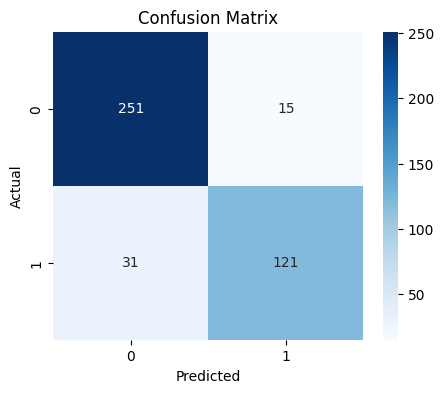

In [754]:
cm = confusion_matrix(Y_test, p_pred)  
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [755]:
print(classification_report(Y_test, p_pred))


              precision    recall  f1-score   support

           0       0.89      0.94      0.92       266
           1       0.89      0.80      0.84       152

    accuracy                           0.89       418
   macro avg       0.89      0.87      0.88       418
weighted avg       0.89      0.89      0.89       418



In [756]:
count=0
for i in range(len(p_pred)):
    if (p_pred[i]==Y_test[i]):
        count+=1
print("Accuracy: ",count*100/len(p_pred))

Accuracy:  88.99521531100478
